# TikTok Topic and Category Quality Report

This notebook evaluates AI-generated topics and categories from Mongo `tiktok_user_video`.

## Scope changes vs YouTube report
- Collection: `tiktok_user_video`
- Comment strength field: `comments_count` (instead of `comments_count_relevance`)

## Outputs
- Coverage and distribution metrics
- Topic/category consistency checks
- CSV metrics export
- Comments-per-video plot

In [5]:
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from dotenv import load_dotenv
    load_dotenv("/opt/airflow/.env", override=True)
except Exception:
    pass

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB", "rbl")
MONGO_VIDEOS_COLLECTION = os.getenv("MONGO_TIKTOK_VIDEOS_COLLECTION", "tiktok_user_video")

OUTPUT_DIR = os.getenv("TOPIC_REPORT_OUTPUT_DIR", "/opt/airflow/notebooks/outputs/topic_quality_report_tiktok")
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not MONGODB_URI:
    raise ValueError("Set MONGODB_URI in environment first.")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
print("collection:", MONGO_VIDEOS_COLLECTION)
print("output dir:", OUTPUT_DIR)

collection: tiktok_user_video
output dir: /opt/airflow/notebooks/outputs/topic_quality_report_tiktok


In [6]:
# Load TikTok video documents from Mongo.
mongo = MongoClient(MONGODB_URI)
coll = mongo[MONGODB_DB][MONGO_VIDEOS_COLLECTION]

query = {"video_id": {"$exists": True, "$nin": [None, ""]}}
projection = {
    "_id": 0,
    "video_id": 1,
    "username": 1,
    "comments_analyzed_at": 1,
    "comments_count": 1,
    "comments_frequent_topics": 1,
    "comments_frequent_topic_categories": 1,
    "comments_frequent_topic_weights": 1,
    "comments_frequent_topics_json": 1,
}

docs = list(coll.find(query, projection=projection))
mongo.close()

videos_df = pd.DataFrame(docs)
if "comments_count" not in videos_df.columns:
    videos_df["comments_count"] = 0
videos_df["comments_count"] = pd.to_numeric(videos_df["comments_count"], errors="coerce").fillna(0).astype(int)

videos_with_topics = videos_df["comments_frequent_topics"].apply(lambda x: isinstance(x, list) and len(x) > 0) if "comments_frequent_topics" in videos_df.columns else pd.Series(dtype=bool)
videos_topics_df = videos_df.loc[videos_with_topics].copy() if len(videos_df) else videos_df.copy()
videos_with_comments = videos_topics_df["comments_count"] > 0 if len(videos_topics_df) else pd.Series(dtype=bool)

print("videos loaded (all):", len(videos_df))
print("videos in report scope (with topics):", len(videos_topics_df))
print("scope videos with comments_count > 0:", int(videos_with_comments.sum()) if len(videos_with_comments) else 0)
print("scope videos with comments_count = 0:", int((~videos_with_comments).sum()) if len(videos_with_comments) else 0)

videos_topics_df.head(3)

/tmp/ipykernel_196/766908275.py:2: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  mongo = MongoClient(MONGODB_URI)


videos loaded (all): 17876
videos in report scope (with topics): 17313
scope videos with comments_count > 0: 17312
scope videos with comments_count = 0: 1


,video_id,username,comments_analyzed_at,comments_count,comments_frequent_topics,comments_frequent_topic_categories,comments_frequent_topic_weights,comments_frequent_topics_json
0,7203716158049094917,zarajanice,2026-03-17 16:17:29.226,9,"[Pregnancy, Aesthetics and Looks, Compliments, Tagging Friends]","[Personal Life, Appearance, Reactions, Engagement]","[0.37, 0.33, 0.18, 0.12]","[{""topic"": ""Pregnancy"", ""category"": ""Personal Life"", ""weight"": 0.37}, {""topic"": ""Aesthetics and Looks"", ""category"": ""Appearance"", ""weigh..."
1,7201508150237760774,zarajanice,2026-03-17 16:17:27.021,44,"[Fashion and Style, Physical Transformation, Hair and Curls, Compliments and Beauty, Pregnancy and Life Events, Brand Mentions (Stüssy, ...","[Appearance, Personal Change, Appearance, Reactions, Personal Life, Brands]","[0.4, 0.23, 0.14, 0.13, 0.05, 0.05]","[{""topic"": ""Fashion and Style"", ""category"": ""Appearance"", ""weight"": 0.4}, {""topic"": ""Physical Transformation"", ""category"": ""Personal Cha..."
2,7201203211800202502,zarajanice,2026-03-17 16:17:27.018,64,"[Beauty and Physical Appearance, Confidence and Empowerment, Curly/Natural Hair Appreciation, Intimidation by Men, Age, Attraction and S...","[Compliments, Self-esteem, Haircare, Gender Dynamics, Society, Pop Culture, Advice]","[0.37, 0.18, 0.15, 0.12, 0.1, 0.05, 0.03]","[{""topic"": ""Beauty and Physical Appearance"", ""category"": ""Compliments"", ""weight"": 0.37}, {""topic"": ""Confidence and Empowerment"", ""catego..."


In [7]:
# Flatten per-video topics into per-topic rows.
rows = []
for _, r in videos_topics_df.iterrows():
    video_id = r.get("video_id")
    username = r.get("username")
    comments_count = int(r.get("comments_count") or 0)

    topics = r.get("comments_frequent_topics") or []
    weights = r.get("comments_frequent_topic_weights") or []
    categories = r.get("comments_frequent_topic_categories") or []

    # Fallback: if topics_json includes category keys, parse them.
    if (not categories) and isinstance(r.get("comments_frequent_topics_json"), str):
        try:
            parsed = json.loads(r.get("comments_frequent_topics_json"))
            if isinstance(parsed, list):
                categories = [str(x.get("category", "")).strip() if isinstance(x, dict) else "" for x in parsed]
        except Exception:
            pass

    for i, topic in enumerate(topics):
        if not isinstance(topic, str) or not topic.strip():
            continue
        w = 0.0
        if i < len(weights):
            try:
                w = float(weights[i])
            except Exception:
                w = 0.0
        cat = ""
        if i < len(categories) and isinstance(categories[i], str):
            cat = categories[i].strip()
        if not cat:
            cat = "Uncategorized"

        rows.append(
            {
                "video_id": video_id,
                "username": username,
                "comments_count": comments_count,
                "topic": topic.strip(),
                "category": cat,
                "weight": w,
            }
        )

topic_rows = pd.DataFrame(rows)
print("flattened topic rows:", len(topic_rows))
print("unique topics:", topic_rows["topic"].nunique() if len(topic_rows) else 0)
print("unique categories:", topic_rows["category"].nunique() if len(topic_rows) else 0)
print("min comments_count in analysis set:", int(topic_rows["comments_count"].min()) if len(topic_rows) else 0)

topic_rows.head(5)

flattened topic rows: 110591
unique topics: 82203
unique categories: 9944
min comments_count in analysis set: 0


,video_id,username,comments_count,topic,category,weight
0,7203716158049094917,zarajanice,9,Pregnancy,Personal Life,0.37
1,7203716158049094917,zarajanice,9,Aesthetics and Looks,Appearance,0.33
2,7203716158049094917,zarajanice,9,Compliments,Reactions,0.18
3,7203716158049094917,zarajanice,9,Tagging Friends,Engagement,0.12
4,7201508150237760774,zarajanice,44,Fashion and Style,Appearance,0.40


In [8]:
# 1) Descriptive metrics.
covered_videos = topic_rows["video_id"].nunique()
all_videos = videos_topics_df["video_id"].nunique()
coverage = covered_videos / all_videos if all_videos else 0.0

per_video_topic_count = topic_rows.groupby("video_id")["topic"].count().rename("topics_per_video")
avg_topics_per_video = float(per_video_topic_count.mean()) if len(per_video_topic_count) else 0.0

# Per-video category volume (unique categories per video).
per_video_category_count = topic_rows.groupby("video_id")["category"].nunique().rename("categories_per_video")
avg_categories_per_video = float(per_video_category_count.mean()) if len(per_video_category_count) else 0.0

topic_stats = (
    topic_rows.groupby("topic", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
    )
    .sort_values("total_weight", ascending=False)
)

category_stats = (
    topic_rows.groupby("category", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        rows_count=("topic", "count"),
        total_weight=("weight", "sum"),
    )
    .sort_values("total_weight", ascending=False)
)

print(f"coverage (videos with topics): {covered_videos}/{all_videos} ({coverage:.2%})")
print("average topics/video:", round(avg_topics_per_video, 2))
print("median topics/video:", per_video_topic_count.median())
print("p90 topics/video:", per_video_topic_count.quantile(0.90))
print("average categories/video:", round(avg_categories_per_video, 2))
print("median categories/video:", per_video_category_count.median())
print("p90 categories/video:", per_video_category_count.quantile(0.90))
print("\nTop topics by total_weight")
display(topic_stats.head(20))
print("\nTop categories by total_weight")
display(category_stats.head(20))

coverage (videos with topics): 17313/17313 (100.00%)
average topics/video: 6.39
median topics/video: 7.0
p90 topics/video: 10.0
average categories/video: 5.75
median categories/video: 6.0
p90 categories/video: 9.0

Top topics by total_weight


,topic,videos_count,total_weight,mean_weight
14929,Compliments on Appearance,374,117.58,0.314385
14732,Compliments,290,85.63,0.295276
56638,Positive Reactions,346,85.06,0.245838
35066,Humor,265,73.24,0.276377
35271,Humor and Laughter,209,58.86,0.281627
3238,Appearance Compliments,168,54.74,0.325833
60576,Real Madrid,82,43.88,0.535122
60666,Real Madrid Support,127,43.56,0.342992
40647,Laughter,56,40.76,0.727857
17557,Cuteness,85,36.64,0.431059



Top categories by total_weight


,category,videos_count,rows_count,total_weight
2579,Engagement,4431,5060,826.690
1371,Community,3213,3529,438.520
3193,Fashion,1620,1933,418.650
2595,Entertainment,2285,2384,406.220
8043,Sentiment,2165,2318,405.955
2520,Emotion,1413,1572,388.100
4366,Humor,1774,1937,320.805
254,Appearance,944,1112,249.640
269,Appreciation,900,925,233.605
2555,Emotions,810,882,202.730


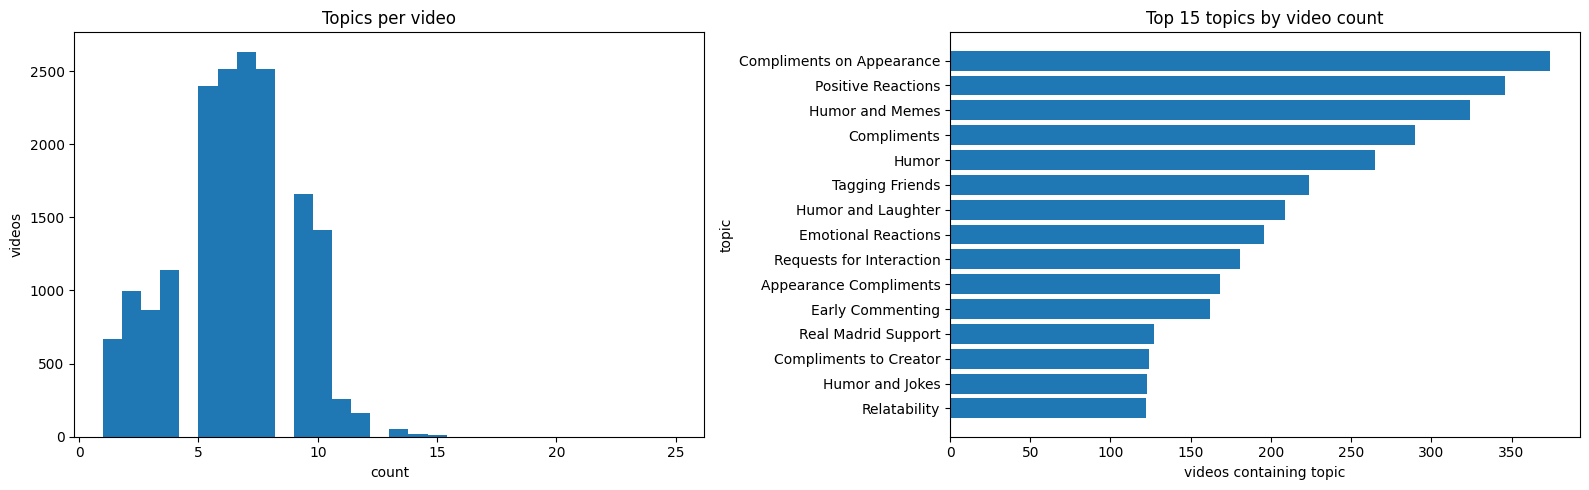

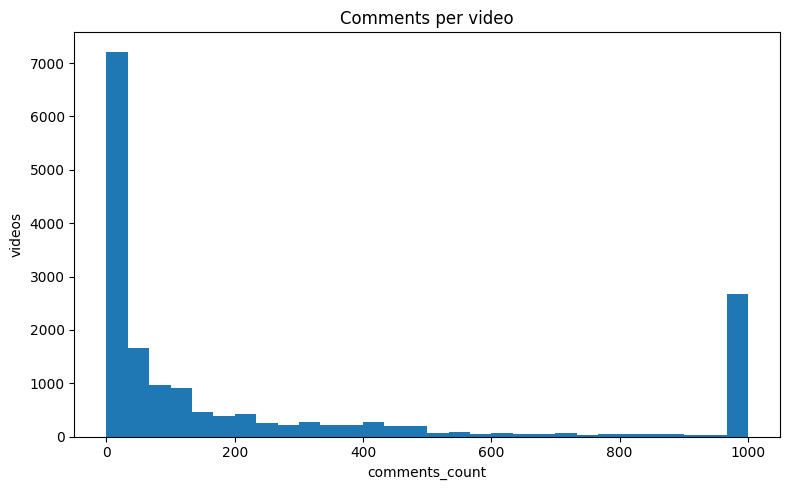

comments_count summary


count    17313.000000
mean       256.362733
std        359.448972
min          0.000000
10%          2.000000
25%         10.000000
50%         61.000000
75%        364.000000
90%       1000.000000
max       1000.000000
Name: comments_count, dtype: float64

saved standalone plot: /opt/airflow/notebooks/outputs/topic_quality_report_tiktok/tiktok_comments_per_video.png


In [ ]:
# 2) Distribution plots (same style as the reference report).
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_video_topic_count.values, bins=30)
axes[0].set_title("Topics per video")
axes[0].set_xlabel("count")
axes[0].set_ylabel("videos")

# Easier-to-read alternative to log-log long-tail.
top_topics = (
    topic_rows.groupby("topic")["video_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)
axes[1].barh(top_topics.index, top_topics.values)
axes[1].set_title("Top 15 topics by video count")
axes[1].set_xlabel("videos containing topic")
axes[1].set_ylabel("topic")

plt.tight_layout()

distribution_panel_path = os.path.join(OUTPUT_DIR, "tiktok_distribution_panel.png")
fig.savefig(distribution_panel_path, dpi=180, bbox_inches="tight")
plt.show()

# Standalone chart: how many topics each processed video has.
fig_topics, ax_topics = plt.subplots(figsize=(8, 5))
ax_topics.hist(per_video_topic_count.values, bins=30)
ax_topics.set_title("Topics per video")
ax_topics.set_xlabel("topics_per_video")
ax_topics.set_ylabel("videos")
plt.tight_layout()

topics_hist_path = os.path.join(OUTPUT_DIR, "tiktok_topics_per_video.png")
fig_topics.savefig(topics_hist_path, dpi=180, bbox_inches="tight")
plt.show()

# Standalone chart: how many comments each processed video has.
comment_counts = videos_topics_df["comments_count"].dropna()

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(comment_counts.values, bins=30)
ax2.set_title("Comments per video")
ax2.set_xlabel("comments_count")
ax2.set_ylabel("videos")
plt.tight_layout()

comments_hist_path = os.path.join(OUTPUT_DIR, "tiktok_comments_per_video.png")
fig2.savefig(comments_hist_path, dpi=180, bbox_inches="tight")
plt.show()

print("comments_count summary")
display(comment_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print("saved standalone plots:", topics_hist_path, "and", comments_hist_path)

In [10]:
# 1b) Simple lexical normalization for topic-label fragmentation.
import re


def normalize_topic_label(topic: str) -> str:
    """Build a lightweight canonical key from a topic label.

    This is intentionally lexical (not embedding-based): lowercase, strip punctuation,
    drop common connector words, singularize simple plurals, and sort tokens so
    reorderings like 'Humor and Laughter' / 'Laughter and Humor' collapse together.
    """
    if not isinstance(topic, str):
        return "<missing>"

    text = topic.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t]

    # Drop weak connector tokens that do not carry topic meaning.
    stop_tokens = {
        "and", "or", "the", "a", "an", "of", "for", "to", "in", "on", "with", "about"
    }

    cleaned = []
    for t in tokens:
        if t in stop_tokens:
            continue
        # Naive singularization for simple plural forms.
        if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
            t = t[:-1]
        cleaned.append(t)

    if not cleaned:
        return "<empty>"

    return " ".join(sorted(set(cleaned)))


topic_rows_norm = topic_rows.copy()
topic_rows_norm["topic_norm_key"] = topic_rows_norm["topic"].apply(normalize_topic_label)

raw_unique_topics = int(topic_rows_norm["topic"].nunique())
norm_unique_topics = int(topic_rows_norm["topic_norm_key"].nunique())

norm_topic_stats = (
    topic_rows_norm.groupby("topic_norm_key", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
        raw_topic_labels=("topic", lambda s: sorted(set(s))),
    )
    .sort_values("total_weight", ascending=False)
)

norm_topic_stats["raw_label_count"] = norm_topic_stats["raw_topic_labels"].apply(len)
norm_topic_stats["example_labels"] = norm_topic_stats["raw_topic_labels"].apply(lambda xs: "; ".join(xs[:5]))

print("raw unique topics:", raw_unique_topics)
print("normalized topic keys:", norm_unique_topics)
if raw_unique_topics > 0:
    print("reduction:", f"{(1 - norm_unique_topics / raw_unique_topics):.2%}")

print("\nTop normalized topics by total_weight")
display(norm_topic_stats[["topic_norm_key", "videos_count", "total_weight", "mean_weight", "raw_label_count", "example_labels"]].head(20))

print("\nMost fragmented normalized keys (many raw labels merged)")
display(norm_topic_stats.sort_values("raw_label_count", ascending=False)[["topic_norm_key", "raw_label_count", "example_labels", "videos_count", "total_weight"]].head(20))

raw unique topics: 82203
normalized topic keys: 72744
reduction: 11.51%

Top normalized topics by total_weight


,topic_norm_key,videos_count,total_weight,mean_weight,raw_label_count,example_labels
9854,appearance compliment,727,220.19,0.302875,21,Appearance Compliment; Appearance Compliments; Appearance and Compliments; Appearance compliments; Appearance/Compliments
58145,humor laughter,368,107.40,0.291848,10,Humor & Laughter; Humor / Laughter; Humor and Laughter; Humor and laughter; Humor/Laughter
69449,positive reaction,400,105.02,0.262550,4,Positive Reaction; Positive Reactions; Positive reaction; Positive reactions
33976,compliment,303,93.28,0.307855,2,Compliment; Compliments
58079,humor,265,73.24,0.276377,1,Humor
58175,humor meme,480,50.66,0.105542,12,Humor & Memes; Humor & memes; Humor / Memes; Humor and Memes; Humor and memes
58107,humor joke,279,47.59,0.170573,9,Humor & Jokes; Humor / Jokes; Humor and Jokes; Humor and jokes; Humor/Jokes
64143,madrid real support,143,47.11,0.329441,3,Real Madrid Support; Real Madrid support; Support for Real Madrid
64119,madrid real,82,43.88,0.535122,1,Real Madrid
53302,friend tagging,273,42.84,0.156923,9,Friend Tagging; Friend/Tagging; Friends Tagging; Friends and Tagging; Friends tagging



Most fragmented normalized keys (many raw labels merged)


,topic_norm_key,raw_label_count,example_labels,videos_count,total_weight
31326,comment early first,35,'First' or Early Comments; Early / First Comments; Early Comment (First); Early Comments & Firsts; Early Comments ('First'),115,10.93
52213,follow request support,24,"Request for support, follows; Requests for Follow/Support; Requests for Follows & Support; Requests for Follows and Support; Requests fo...",113,25.13
9854,appearance compliment,21,Appearance Compliment; Appearance Compliments; Appearance and Compliments; Appearance compliments; Appearance/Compliments,727,220.19
3681,admin interaction request,21,Admin Interaction Request; Admin Interaction Requests; Admin Interaction and Requests; Admin Interaction/Requests; Admin Requests and In...,27,2.13
60100,interaction replie request,18,Replies and Interaction Requests; Request for Interaction/Replies; Request for Replies/Interaction; Requests for Interaction and Replies...,73,8.89
55926,greeting request,17,Greeting Request; Greeting Requests; Greetings Requests; Greetings and Requests; Greetings and requests,87,20.18
45570,emoji positive reaction,17,Emojis and Positive Reactions; Emojis and positive reactions; Emojis/Positive Reaction; Emojis/Positive Reactions; Positive Emoji Reaction,76,12.93
50549,fashion outfit,17,Fashion & Outfits; Fashion / Outfits; Fashion Outfit; Fashion Outfits; Fashion and Outfit,193,37.84
60108,interaction request,16,Interaction Request; Interaction Requests; Interaction requests; Interaction/Requests; Interactions and Requests,247,28.56
29447,club comparison other player,16,Comparison to Other Clubs/Players; Comparison to Other Players/Clubs; Comparison to other clubs and players; Comparison to other clubs/p...,29,1.87


In [11]:
# 3) Overall entropy summary (all scoped videos with topics)
def shannon_entropy(ws):
    arr = np.array(ws, dtype=float)
    arr = arr[arr > 0]
    if arr.size == 0:
        return 0.0
    p = arr / arr.sum()
    return float(-(p * np.log2(p)).sum())

video_entropy = (
    topic_rows.groupby("video_id")["weight"]
    .apply(shannon_entropy)
    .rename("topic_entropy")
)

print("Entropy summary")
display(video_entropy.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

Entropy summary


count    17313.000000
mean         2.248143
std          0.693340
min         -0.000000
10%          1.295462
25%          2.011349
50%          2.418310
75%          2.693255
90%          2.916239
max          4.440130
Name: topic_entropy, dtype: float64

Topic diversity by comments_count bucket


,comment_bucket,videos,mean_diversity,median_diversity,p10,p90
0,1-10,4369,1.397993,1.566615,-0.000000,2.254600
1,11-50,3865,2.320021,2.336849,1.941117,2.689710
2,51-200,3393,2.555084,2.560340,2.170448,2.940028
3,200+,5686,2.669362,2.690917,2.265470,3.065238


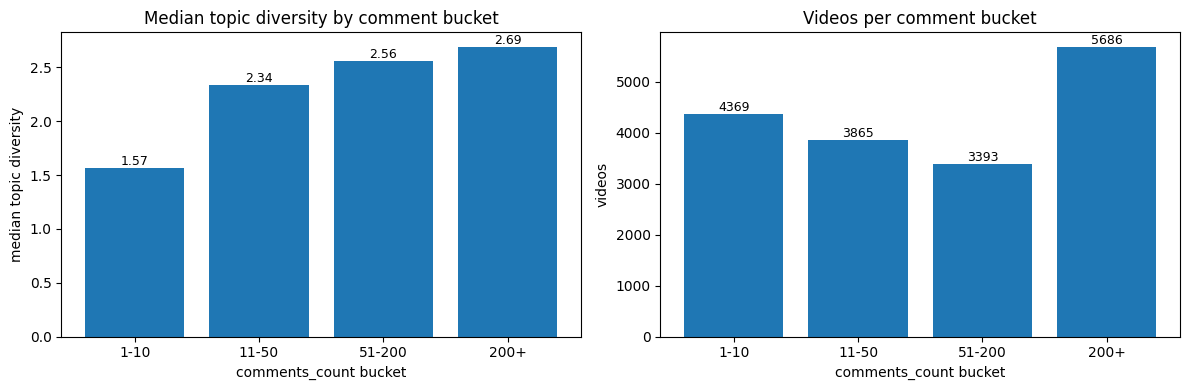

In [12]:
# 3b) Topic diversity by comments_count bucket.
# Helps interpret whether low topic diversity is evidence of focus or just low sample size.

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count"]
    .max()
    .rename("comments_count")
)

entropy_with_comments = pd.concat([video_entropy, per_video_comments], axis=1).dropna()

bins = [0, 10, 50, 200, np.inf]
labels = ["1-10", "11-50", "51-200", "200+"]
entropy_with_comments["comment_bucket"] = pd.cut(
    entropy_with_comments["comments_count"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

bucket_summary = (
    entropy_with_comments.groupby("comment_bucket", observed=True)["topic_entropy"]
    .agg(
        videos="count",
        mean_diversity="mean",
        median_diversity="median",
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

print("Topic diversity by comments_count bucket")
display(bucket_summary)

# Simpler visualization: median topic diversity + sample size per bucket.
plot_df = bucket_summary.copy()
plot_df["comment_bucket"] = pd.Categorical(plot_df["comment_bucket"], categories=labels, ordered=True)
plot_df = plot_df.sort_values("comment_bucket")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_df["comment_bucket"].astype(str), plot_df["median_diversity"])
axes[0].set_title("Median topic diversity by comment bucket")
axes[0].set_xlabel("comments_count bucket")
axes[0].set_ylabel("median topic diversity")
for i, v in enumerate(plot_df["median_diversity"]):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

axes[1].bar(plot_df["comment_bucket"].astype(str), plot_df["videos"])
axes[1].set_title("Videos per comment bucket")
axes[1].set_xlabel("comments_count bucket")
axes[1].set_ylabel("videos")
for i, v in enumerate(plot_df["videos"]):
    axes[1].text(i, v + max(plot_df["videos"]) * 0.01, f"{int(v)}", ha="center", fontsize=9)

plt.tight_layout()

diversity_bucket_plot_path = os.path.join(OUTPUT_DIR, "tiktok_topic_diversity_by_comments_bucket.png")
fig.savefig(diversity_bucket_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved plot:", diversity_bucket_plot_path)

low-entropy threshold: 1.2955
videos in focused subset: 1735
focused subset comments_count summary


count    1735.000000
mean        5.239769
std        49.376518
min         1.000000
10%         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
90%         3.000000
max      1000.000000
Name: comments_count, dtype: float64

focused subset by comments_count bucket


,videos
comment_bucket,
1-10,1709
11-50,13
51-100,2
101-300,3
301-600,4
601-1000,4


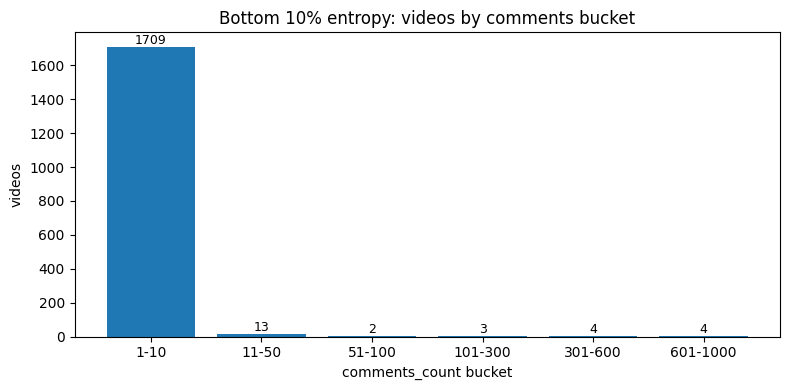


Bucket 1-10 - videos: 1709


dominant_topic
Laughter              40
Compliments           33
Cuteness              21
Humor                 19
Greetings             17
Affection             17
Positive Emotions     16
Positive Reactions    16
Excitement            15
Admiration            12
Name: count, dtype: int64

dominant_category
Engagement      147
Emotion         117
Fashion          56
Emotions         44
Appreciation     41
Compliment       37
Sentiment        36
Reaction         32
Sports           29
Appearance       29
Name: count, dtype: int64


Bucket 11-50 - videos: 13


dominant_topic
Beauty and Appearance                                                     1
Mint Green Outfit                                                         1
Compliments on Appearance                                                 1
Barcelona                                                                 1
Soda Brand Preferences                                                    1
Players (Frenkie, De Ligt, Ake, Verbruggen, Gakpo, Cody, Joey Veerman)    1
Outfit Sources                                                            1
Request for Part 2                                                        1
Screen Time Duration                                                      1
Parents using TikTok                                                      1
Name: count, dtype: int64

...

dominant_topic
4-0 Scoreline                   1
Dries Mertens Birthday          1
Birthday Wishes for Vini Jr.    1
BTS and the song 'Fire'         1
Name: count, dtype: int64

dominant_category
Celebration     2
Match Result    1
Music           1
Name: count, dtype: int64

,video_id,dominant_topic,dominant_category,dominant_weight,comments_count,comment_bucket
1,7183702121617968389,New Year Wishes,Celebration,1.0,1,1-10
3,7184412517534321925,Good Wishes,Positivity,1.0,1,1-10
7,7184799249434021126,Flirtation,Relationships,1.0,1,1-10
9,7184814880455789829,Flu Meaning,Clarification,1.0,1,1-10
10,7184849236859571462,User Mention,Engagement,1.0,1,1-10
11,7185012246123252997,Not Me,Self-Identification,1.0,1,1-10
12,7185116948764675333,Clothing Quality,Fashion,1.0,1,1-10
13,7185145633903217925,Appearance Compliment,Praise,1.0,1,1-10
14,7185159442797841670,First Commenting,Participation,1.0,1,1-10
16,7185527908868361478,Cuteness,Compliment,1.0,1,1-10


dominant_topic
Laughter                     40
Compliments                  33
Cuteness                     21
Humor                        19
Greetings                    17
Affection                    17
Positive Emotions            16
Positive Reactions           16
Excitement                   15
Compliments on Appearance    13
Admiration                   12
Positive Reaction            11
Appearance Compliments       10
Positive Feedback            10
Love                          9
Compliment                    7
User Mention                  7
Appreciation                  6
Complimenting Appearance      6
Confusion                     6
Name: count, dtype: int64

dominant_category
Engagement             149
Emotion                118
Fashion                 58
Emotions                44
Appreciation            42
Compliment              37
Sentiment               36
Reaction                33
Appearance              30
Sports                  29
Praise                  26
Entertainment           23
Humor                   23
Social Interaction      21
Relationships           20
Personal Experience     20
Interaction             19
Positive Feedback       18
Compliments             16
Reactions               15
Name: count, dtype: int64

In [13]:
# Join entropy with topic rows and find dominant topic per low-entropy videos.
# Includes comments_count and granular buckets for evidence-strength context.
low_thr = video_entropy.quantile(0.10)  # bottom 10% entropy
low_entropy_videos = set(video_entropy[video_entropy <= low_thr].index)

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count"]
    .max()
    .rename("comments_count")
    .reset_index()
)

dominant = (
    topic_rows[topic_rows["video_id"].isin(low_entropy_videos)]
    .sort_values(["video_id", "weight"], ascending=[True, False])
    .groupby("video_id", as_index=False)
    .first()[["video_id", "topic", "category", "weight"]]
    .rename(columns={"topic": "dominant_topic", "category": "dominant_category", "weight": "dominant_weight"})
    .merge(per_video_comments, on="video_id", how="left")
)

print("low-entropy threshold:", round(float(low_thr), 4))
print("videos in focused subset:", len(dominant))
print("focused subset comments_count summary")
display(dominant["comments_count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

focus_bins = [0, 10, 50, 100, 300, 600, 1000]
focus_labels = ["1-10", "11-50", "51-100", "101-300", "301-600", "601-1000"]

dominant["comment_bucket"] = pd.cut(
    dominant["comments_count"],
    bins=focus_bins,
    labels=focus_labels,
    include_lowest=True,
)
focus_bucket_counts = dominant["comment_bucket"].value_counts().reindex(focus_labels, fill_value=0)

print("focused subset by comments_count bucket")
display(focus_bucket_counts.rename("videos").to_frame())

plt.figure(figsize=(8, 4))
bars = plt.bar(focus_bucket_counts.index.astype(str), focus_bucket_counts.values)
plt.title("Bottom 10% entropy: videos by comments bucket")
plt.xlabel("comments_count bucket")
plt.ylabel("videos")
for b, v in zip(bars, focus_bucket_counts.values):
    plt.text(b.get_x() + b.get_width() / 2, v + max(focus_bucket_counts.values.tolist() + [1]) * 0.01, f"{int(v)}", ha="center", fontsize=9)
plt.tight_layout()

low_entropy_bucket_plot_path = os.path.join(OUTPUT_DIR, "tiktok_low_entropy_videos_by_comments_bucket.png")
plt.savefig(low_entropy_bucket_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved plot:", low_entropy_bucket_plot_path)

for b in focus_labels:
    d = dominant[dominant["comment_bucket"] == b]
    if d.empty:
        continue
    print(f"\nBucket {b} - videos: {len(d)}")
    display(d["dominant_topic"].value_counts().head(10))
    display(d["dominant_category"].value_counts().head(10))

display(dominant.sort_values(["comments_count", "dominant_weight"], ascending=[True, False]).head(30))
display(dominant["dominant_topic"].value_counts().head(20))
display(dominant["dominant_category"].value_counts().head(20))

In [14]:
# 4) Redundancy and category consistency proxy via label similarity (ultra-light).
# This version is intentionally conservative to avoid kernel crashes.
if "topic_rows" not in globals():
    raise RuntimeError("topic_rows is not defined. Run the flatten-topics cell first.")

from sklearn.neighbors import NearestNeighbors

unique_topics = topic_rows[["topic", "category"]].drop_duplicates(subset=["topic"]).reset_index(drop=True)
full_n_topics = len(unique_topics)

# Limit analysis to a random topic sample so memory/runtime stays bounded.
sample_topics_n = 8000
sampled_topics = unique_topics.sample(n=min(sample_topics_n, full_n_topics), random_state=42).reset_index(drop=True)

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=80000)
X = vec.fit_transform(sampled_topics["topic"])
n_topics = X.shape[0]

near_dup_threshold = 0.85
max_neighbors = 8
k = min(max_neighbors, n_topics)

# 4a) Approx near-duplicate detection on sampled topics only.
if k <= 1:
    near_dup_df = pd.DataFrame(columns=["topic_a", "cat_a", "topic_b", "cat_b", "similarity"])
else:
    nn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    seen_pairs = set()
    near_dup_rows = []
    for i in range(n_topics):
        for rank in range(1, k):  # rank 0 is self
            j = int(indices[i, rank])
            sim = 1.0 - float(distances[i, rank])
            if sim < near_dup_threshold:
                continue
            a, b = (i, j) if i < j else (j, i)
            if a == b or (a, b) in seen_pairs:
                continue
            seen_pairs.add((a, b))
            near_dup_rows.append(
                {
                    "topic_a": sampled_topics.loc[a, "topic"],
                    "cat_a": sampled_topics.loc[a, "category"],
                    "topic_b": sampled_topics.loc[b, "topic"],
                    "cat_b": sampled_topics.loc[b, "category"],
                    "similarity": sim,
                }
            )

    near_dup_df = pd.DataFrame(near_dup_rows)
    if len(near_dup_df):
        near_dup_df = near_dup_df.sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"topics total: {full_n_topics}, sampled: {n_topics}, neighbors per topic: {k}")
print("near-duplicate topic pairs (>=0.85) in sample:", len(near_dup_df))
display(near_dup_df.head(30))

# 4b) Category consistency from sampled pairs (sampled topics only).
rng = np.random.default_rng(42)
cat_vals = sampled_topics["category"].to_numpy()
cat_to_idx = sampled_topics.groupby("category").indices

sample_pairs_target = 5000

within_pairs = set()
valid_cats = [c for c, idx in cat_to_idx.items() if len(idx) >= 2]
attempts = 0
max_attempts = sample_pairs_target * 40
while len(within_pairs) < sample_pairs_target and attempts < max_attempts and valid_cats:
    c = valid_cats[int(rng.integers(0, len(valid_cats)))]
    idx = np.asarray(cat_to_idx[c], dtype=int)
    i, j = rng.choice(idx, size=2, replace=False)
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    within_pairs.add((a, b))
    attempts += 1

between_pairs = set()
attempts = 0
all_idx = np.arange(n_topics)
while len(between_pairs) < sample_pairs_target and attempts < max_attempts and n_topics >= 2:
    i, j = rng.choice(all_idx, size=2, replace=False)
    if cat_vals[i] == cat_vals[j]:
        attempts += 1
        continue
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    between_pairs.add((a, b))
    attempts += 1


def pair_sims_from_index_pairs(X_sparse, pair_set):
    if not pair_set:
        return np.array([], dtype=float)
    pair_arr = np.array(list(pair_set), dtype=int)
    a_idx = pair_arr[:, 0]
    b_idx = pair_arr[:, 1]
    sims = X_sparse[a_idx].multiply(X_sparse[b_idx]).sum(axis=1).A1
    return sims.astype(float)

within = pair_sims_from_index_pairs(X, within_pairs)
between = pair_sims_from_index_pairs(X, between_pairs)

print("within sample pairs:", len(within), "between sample pairs:", len(between))
print("avg within-category similarity (sample):", round(float(np.mean(within)) if len(within) else 0.0, 4))
print("avg between-category similarity (sample):", round(float(np.mean(between)) if len(between) else 0.0, 4))

topics total: 82203, sampled: 8000, neighbors per topic: 8
near-duplicate topic pairs (>=0.85) in sample: 236


,topic_a,cat_a,topic_b,cat_b,similarity
0,Messi and Ronaldo rivalry,Football Legends,Ronaldo and Messi Rivalry,Football Legends,1.0
1,Friendship and community,Community,Friendship and Community,Social,1.0
2,Fan Personal Stories,Personal Sharing,Personal Fan Stories,Fan Experience,1.0
3,Jokes & Memes,Entertainment,Memes & Jokes,Humor,1.0
4,Fan Support and Appreciation,Community,Fan Appreciation and Support,Community,1.0
5,Fan support and excitement,Community,Fan Support and Excitement,Community Sentiment,1.0
6,Requests and Fan Interaction,Engagement,Fan Interaction and Requests,Engagement,1.0
7,Comeback excitement,Comeback,Comeback Excitement,Fandom,1.0
8,Effort and Hard Work,Motivation,Hard Work and Effort,Performance,1.0
9,Chelsea Signing Players,Transfers,Chelsea signing players,Transfers,1.0


within sample pairs: 5000 between sample pairs: 5000
avg within-category similarity (sample): 0.0739
avg between-category similarity (sample): 0.0113


In [15]:
# 5) Co-occurrence diagnostics.
def top_cooccurrence_pairs(df, col, top_n=30):
    counts = Counter()
    for _, g in df.groupby("video_id"):
        vals = sorted(set(str(v).strip() for v in g[col].dropna().tolist() if str(v).strip()))
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                counts[(vals[i], vals[j])] += 1
    out = pd.DataFrame([
        {"a": a, "b": b, "cooccur_videos": c} for (a, b), c in counts.most_common(top_n)
    ])
    return out

print("Top topic co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "topic", top_n=25))

print("Top category co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "category", top_n=25))

Top topic co-occurrence pairs


,a,b,cooccur_videos
0,Cristiano Ronaldo,Real Madrid Support,30
1,Cristiano Ronaldo,Real Madrid,28
2,Positive Reactions,Product Availability,28
3,Humor,Relatability,24
4,Compliments on Appearance,Requests for Interaction,19
5,Positive Reactions,Tagging Friends,17
6,Compliments,Humor,16
7,Barcelona Rivalry,Real Madrid Support,16
8,Cristiano Ronaldo,Jude Bellingham,16
9,Humor and Laughter,Tagging Friends,15


Top category co-occurrence pairs


,a,b,cooccur_videos
0,Community,Engagement,1032
1,Engagement,Entertainment,636
2,Community,Entertainment,631
3,Engagement,Sentiment,588
4,Engagement,Fashion,560
5,Engagement,Humor,458
6,Community,Sentiment,405
7,Community,Humor,394
8,Emotion,Engagement,367
9,Appreciation,Engagement,366


In [16]:
# 7) Compact metrics export for report deck.
report_rows = [
    {"metric": "scope_videos_with_topics", "value": int(all_videos)},
    {"metric": "videos_with_topic_rows", "value": int(covered_videos)},
    {"metric": "coverage_ratio_within_topic_scope", "value": float(coverage)},
    {"metric": "topic_rows", "value": int(len(topic_rows))},
    {"metric": "unique_topics", "value": int(topic_rows["topic"].nunique())},
    {"metric": "unique_categories", "value": int(topic_rows["category"].nunique())},
    {"metric": "median_topics_per_video", "value": float(per_video_topic_count.median())},
    {"metric": "p90_topics_per_video", "value": float(per_video_topic_count.quantile(0.90))},
    {"metric": "avg_within_category_similarity", "value": float(np.mean(within)) if len(within) else 0.0},
    {"metric": "avg_between_category_similarity", "value": float(np.mean(between)) if len(between) else 0.0},
    {"metric": "near_duplicate_pairs_ge_0.85", "value": int(len(near_dup_df))},
]

report_df = pd.DataFrame(report_rows)
report_path = os.path.join(OUTPUT_DIR, "tiktok_topic_quality_report_metrics.csv")
report_df.to_csv(report_path, index=False)
print("saved metrics csv:", report_path)
display(report_df)

saved metrics csv: /opt/airflow/notebooks/outputs/topic_quality_report_tiktok/tiktok_topic_quality_report_metrics.csv


,metric,value
0,scope_videos_with_topics,17313.000000
1,videos_with_topic_rows,17313.000000
2,coverage_ratio_within_topic_scope,1.000000
3,topic_rows,110591.000000
4,unique_topics,82203.000000
5,unique_categories,9944.000000
6,median_topics_per_video,7.000000
7,p90_topics_per_video,10.000000
8,avg_within_category_similarity,0.073885
9,avg_between_category_similarity,0.011257
